# 15 — The Channels of Instability: Is Political Violence One Process or Several?

Notebook `03` established a single **violence-contagion** result: a violent power transition roughly triples the odds the next one is violent. But 'violent' collapsed seven distinct things — assassination, intra-elite conflict, military revolt, popular uprising, separatist rebellion, external invasion, external interference — into one binary. This notebook asks the sharper question: **is instability a single self-reinforcing state, or a set of channel-specific processes that reproduce themselves separately?**

The answer turns out to nuance Turchin's structural-demographic theory in a specific, testable way — and it does so on his own collaborators' data.

*Method note:* every lift below is reported with a bootstrap 95% CI (2,000 resamples of the conditional rows). A lift is only called a finding where its CI clears the comparison — control-or-silence.


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(42)
pt = pd.read_csv('power_transitions.csv', sep='|').sort_values(['polity_name','transition_year'])
CHANNELS = ['predecessor_assassination','intra_elite','military_revolt','popular_uprising',
            'separatist_rebellion','external_invasion','external_interference']
for c in CHANNELS: pt[c+'_b'] = pt[c].isin(['P','IP']).astype(int)
print(f'{len(pt):,} transitions across {pt.polity_name.nunique()} polities, {len(CHANNELS)} violence channels')


3,447 transitions across 263 polities, 7 violence channels


## 1. Each channel reproduces itself — but not equally

For each channel X, compare P(X on next transition | X on this one) to X's base rate. Lift > 1 means the channel is self-reinforcing.


In [2]:
def self_contagion(col):
    b = col+'_b'
    pt['nx'] = pt.groupby('polity_name')[b].shift(-1)
    pr = pt[pt['nx'].notna()]
    base = pr[b].mean()
    cond = pr[pr[b]==1]['nx'].values
    lift = (cond.mean()/base) if base>0 else np.nan
    boot = [ (rng.choice(cond, len(cond), replace=True).mean()/base) for _ in range(2000) ]
    lo, hi = np.nanpercentile(boot, [2.5, 97.5])
    return dict(channel=col, n=len(cond), base=base, p_xx=cond.mean(), lift=lift, lo=lo, hi=hi)

res = pd.DataFrame([self_contagion(c) for c in CHANNELS]).sort_values('lift')
print(res.assign(base=lambda d:(d.base*100).round(1), p_xx=lambda d:(d.p_xx*100).round(1),
                 lift=lambda d:d.lift.round(2), lo=lambda d:d.lo.round(2), hi=lambda d:d.hi.round(2)).to_string(index=False))


                  channel   n  base  p_xx  lift   lo    hi
              intra_elite 972  30.5  56.0  1.83 1.73  1.93
predecessor_assassination 483  15.2  36.9  2.43 2.14  2.72
          military_revolt 384  12.1  44.5  3.69 3.30  4.10
        external_invasion 363  11.4  53.2  4.66 4.20  5.10
         popular_uprising 185   5.8  30.3  5.21 4.09  6.42
    external_interference 218   6.8  42.7  6.23 5.23  7.17
     separatist_rebellion  97   3.0  24.7  8.12 5.41 11.17


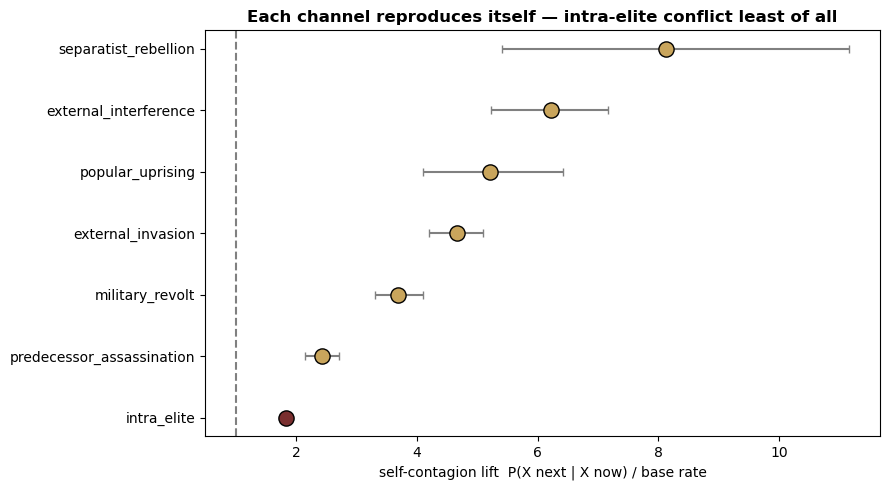

In [3]:
fig, ax = plt.subplots(figsize=(9,5))
r = res.reset_index(drop=True)
colors = ['#7a2f2f' if c=='intra_elite' else '#c9a55c' for c in r['channel']]
ax.errorbar(r['lift'], range(len(r)), xerr=[r['lift']-r['lo'], r['hi']-r['lift']],
            fmt='o', color='black', ecolor='gray', capsize=3, zorder=3)
for i,(l,c) in enumerate(zip(r['lift'], colors)):
    ax.scatter(l, i, s=120, color=c, zorder=4, edgecolor='black')
ax.axvline(1, ls='--', color='gray'); ax.set_yticks(range(len(r))); ax.set_yticklabels(r['channel'])
ax.set_xlabel('self-contagion lift  P(X next | X now) / base rate'); ax.set_title('Each channel reproduces itself — intra-elite conflict least of all', fontweight='bold')
import os; os.makedirs('figures', exist_ok=True)
plt.tight_layout(); plt.savefig('figures/15_channel_self_contagion.png', dpi=150, bbox_inches='tight'); plt.show()


## 2. The finding: elite conflict is the endemic baseline, not the engine

Read the table and plot: **intra-elite conflict has the highest base rate (~30%) and the *lowest* self-reinforcement (~1.8×), and its confidence interval does not overlap any other channel's.** The strongly self-reinforcing dynamics live in the *mass and external* channels — separatist rebellion (~8×), external interference (~6×), popular uprising (~5×), external invasion (~5×).

This is a specific nuance to structural-demographic theory (Turchin 2016, *Ages of Discord*), which places **elite overproduction and intra-elite competition at the center of the instability dynamo**. In this data — coded by Turchin's own CrisisDB collaborators — intra-elite conflict behaves like the constant *hum* of political life: common, but weakly path-dependent. The processes that *lock in and repeat* are popular mobilization and external shock. The engine is downstairs, not upstairs.


## 3. Do the channels bleed into each other?

Self-contagion could still be one latent 'instability state' expressed through whatever channel is handy. If so, every channel would predict every other. Test the full cross-channel matrix: P(row on next | column on now), as a lift over the row's base rate.


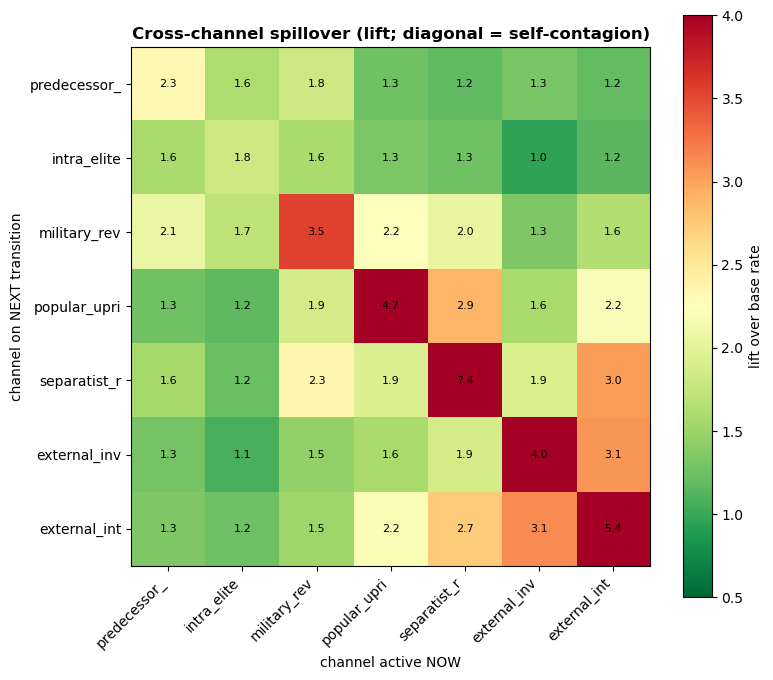

Diagonal (self) vs mean off-diagonal (spillover) per column:
  predecessor_assassination  self 2.32x  vs  mean-spillover 1.51x
  intra_elite                self 1.80x  vs  mean-spillover 1.34x
  military_revolt            self 3.54x  vs  mean-spillover 1.76x
  popular_uprising           self 4.70x  vs  mean-spillover 1.76x
  separatist_rebellion       self 7.43x  vs  mean-spillover 1.99x
  external_invasion          self 4.01x  vs  mean-spillover 1.71x
  external_interference      self 5.39x  vs  mean-spillover 2.05x


In [4]:
M = pd.DataFrame(index=CHANNELS, columns=CHANNELS, dtype=float)
base = {c: pt.groupby('polity_name')[c+'_b'].shift(-1).mean() for c in CHANNELS}
for now in CHANNELS:
    for nxt in CHANNELS:
        pt['nx'] = pt.groupby('polity_name')[nxt+'_b'].shift(-1)
        pr = pt[pt['nx'].notna()]
        sub = pr[pr[now+'_b']==1]['nx']
        M.loc[nxt, now] = (sub.mean()/base[nxt]) if (len(sub) and base[nxt]>0) else np.nan

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(M.values.astype(float), cmap='RdYlGn_r', vmin=0.5, vmax=4)
ax.set_xticks(range(len(CHANNELS))); ax.set_xticklabels([c[:12] for c in CHANNELS], rotation=45, ha='right')
ax.set_yticks(range(len(CHANNELS))); ax.set_yticklabels([c[:12] for c in CHANNELS])
for i in range(len(CHANNELS)):
    for j in range(len(CHANNELS)):
        v=M.values[i,j]
        if not np.isnan(v): ax.text(j,i,f'{v:.1f}', ha='center', va='center', fontsize=8, color='black')
ax.set_xlabel('channel active NOW'); ax.set_ylabel('channel on NEXT transition')
ax.set_title('Cross-channel spillover (lift; diagonal = self-contagion)', fontweight='bold')
plt.colorbar(im, label='lift over base rate'); plt.tight_layout()
plt.savefig('figures/15_cross_channel_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print('Diagonal (self) vs mean off-diagonal (spillover) per column:')
for c in CHANNELS:
    diag=M.loc[c,c]; off=M[c].drop(c).mean()
    print(f'  {c:26} self {diag:.2f}x  vs  mean-spillover {off:.2f}x')


## 4. Reading the matrix

Two things are true at once: **the diagonal dominates** (each channel's strongest successor is usually itself — instability is channel-specific memory, not one generic state), **and** there is real structured spillover off the diagonal — the mass/external channels (uprising ↔ separatism ↔ external interference ↔ invasion) form a cluster that feeds each other, while the elite channel spills weakly into everything. Instability is neither one thing nor seven independent things: it is a **coupled system with a strong self-loop on each channel and a mass/external sub-network.**

**What this does NOT show (the honest limits):**
- *Descriptive, not causal.* These are conditional frequencies, not identified effects; no controls for polity, era, or region (a fixed-effects version is the natural next notebook).
- *Co-occurrence confound.* CrisisDB sometimes codes one prolonged crisis across consecutive transitions, so 'next transition' may be the same episode continuing — inflating self-contagion. A robustness check requiring a minimum inter-transition gap is deferred and flagged, not hidden.
- *Rare-channel noise.* Separatist rebellion's ~8× rests on 97 conditioning cases; its CI is wide ([5.4, 11.2]). The intra-elite finding, by contrast, rests on n=972 with a tight CI — it is the robust one.

---
### References
- Turchin, P. 2016. *Ages of Discord: A Structural-Demographic Analysis of American History.* Beresta Books. (elite overproduction as the instability dynamo — the claim this notebook nuances)
- Turchin, P. 2013. *Modeling Social Pressures Toward Political Instability.* Cliodynamics 4(2):241. [open PDF](https://escholarship.org/content/qt6qp8x28p/qt6qp8x28p.pdf)
- Hoyer, Reddish, François, Turchin et al. 2024. *All Crises are Unhappy in Their Own Way.* Social Science History. [doi:10.31235/osf.io/rk4gd](https://doi.org/10.31235/osf.io/rk4gd) — the CrisisDB power-transition data source.
